# EDA

In [23]:
#!/bin/bash
!curl -L -o ../data/raw/twitter-sentiment-analysis-hatred-speech.zip\
https://www.kaggle.com/api/v1/datasets/download/arkhoshghalb/twitter-sentiment-analysis-hatred-speech

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0--:--:-- --:--:-- --:--:--     0
100 1936k  100 1936k    0     0  1326k      0  0:00:01  0:00:01 --:--:-- 2366k


## 1. Libs

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download("vader_lexicon", quiet=True)
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [13]:
def add_spines(colour="#425169", linewidth=2):
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(colour)
        spine.set_linewidth(linewidth)

def bully_palette(df, col, positions_to_change):
    palette = list(sns.color_palette("mako", n_colors=df[col].nunique()).as_hex())
    for position in positions_to_change:
        if position < len(palette):
            palette[position] = "#cc253b"
    return sns.color_palette(palette)

## 2. Data loading and overview

In [14]:
df = pd.read_csv("../data/raw/train.csv")
df = df.drop(columns=["id"], errors="ignore")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (31962, 2)


,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [15]:
print("--- Data Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Basic Statistics ---")
print(df.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   31962 non-null  int64 
 1   tweet   31962 non-null  object
dtypes: int64(1), object(1)
memory usage: 499.5+ KB

--- Missing Values ---
label    0
tweet    0
dtype: int64

--- Basic Statistics ---
              label
count  31962.000000
mean       0.070146
std        0.255397
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000


## 3. Target variable distribution

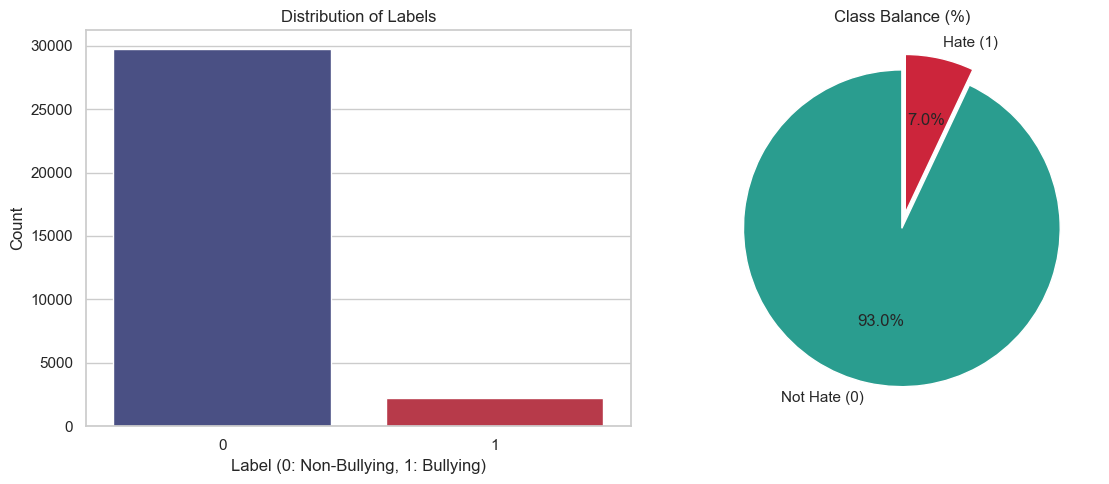


Class distribution:
  Not Hate (0): 29,720 (93.0%)
  Hate (1):     2,242 (7.0%)
  Imbalance ratio: 1:13


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x="label", data=df, palette=bully_palette(df, "label", [1]), ax=axes[0])
axes[0].set_xlabel("Label (0: Non-Bullying, 1: Bullying)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Labels")

# Percentage pie chart
label_counts = df["label"].value_counts()
axes[1].pie(label_counts, labels=["Not Hate (0)", "Hate (1)"],
            autopct="%1.1f%%", colors=["#2a9d8f", "#cc253b"],
            startangle=90, explode=(0, 0.1))
axes[1].set_title("Class Balance (%)")

plt.tight_layout()
plt.show()

print(f"\nClass distribution:")
print(f"  Not Hate (0): {label_counts[0]:,} ({label_counts[0]/len(df)*100:.1f}%)")
print(f"  Hate (1):     {label_counts[1]:,} ({label_counts[1]/len(df)*100:.1f}%)")
print(f"  Imbalance ratio: 1:{label_counts[0]//label_counts[1]}")

> **NOTE:** The dataset has a strong class imbalance. Accuracy is not a good metric here — a model that always predicts class 0 would achieve ~93% accuracy. Therefore, it's important to use F1, Precision, Recall, and ROC-AUC.

## 4. Feature Engineering

In [17]:
def count_symbols(text):
    hashtag_count = len(re.findall(r"#", str(text)))
    mention_count = len(re.findall(r"@", str(text)))
    return hashtag_count, mention_count

df[["num_hashtags", "num_mentions"]] = df["tweet"].apply(lambda x: pd.Series(count_symbols(x)))
df["tweet_len"] = df["tweet"].apply(lambda x: len(str(x)))
df["word_count"] = df["tweet"].apply(lambda x: len(str(x).split()))

# Sentiment analysis
sia = SentimentIntensityAnalyzer()
df["sentiment_score"] = df["tweet"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
df["sentiment"] = df["sentiment_score"].apply(lambda x: "positive" if x >= 0.05 else ("negative" if x <= -0.05 else "neutral"))

print("Feature engineering complete.")
df[["label", "tweet", "num_hashtags", "num_mentions", "tweet_len", "word_count", "sentiment_score"]].head(10)

Feature engineering complete.


,label,tweet,num_hashtags,num_mentions,tweet_len,word_count,sentiment_score
0,0,@user when a father is dysfunctional and is s...,1,1,102,18,-0.8296
1,0,@user @user thanks for #lyft credit i can't us...,3,2,122,19,0.6705
2,0,bihday your majesty,0,0,21,3,0.0000
3,0,#model i love u take with u all the time in ...,1,0,86,14,0.7249
4,0,factsguide: society now #motivation,1,0,39,4,0.0000
5,0,[2/2] huge fan fare and big talking before the...,1,0,116,19,-0.4215
6,0,@user camping tomorrow @user @user @user @use...,0,8,74,11,0.0000
7,0,the next school year is the year for exams.ð...,7,0,143,21,0.0000
8,0,we won!!! love the land!!! #allin #cavs #champ...,5,0,87,11,0.8770
9,0,@user @user welcome here ! i'm it's so #gr...,1,2,50,10,0.5550


## 5. Feature distribution by classes

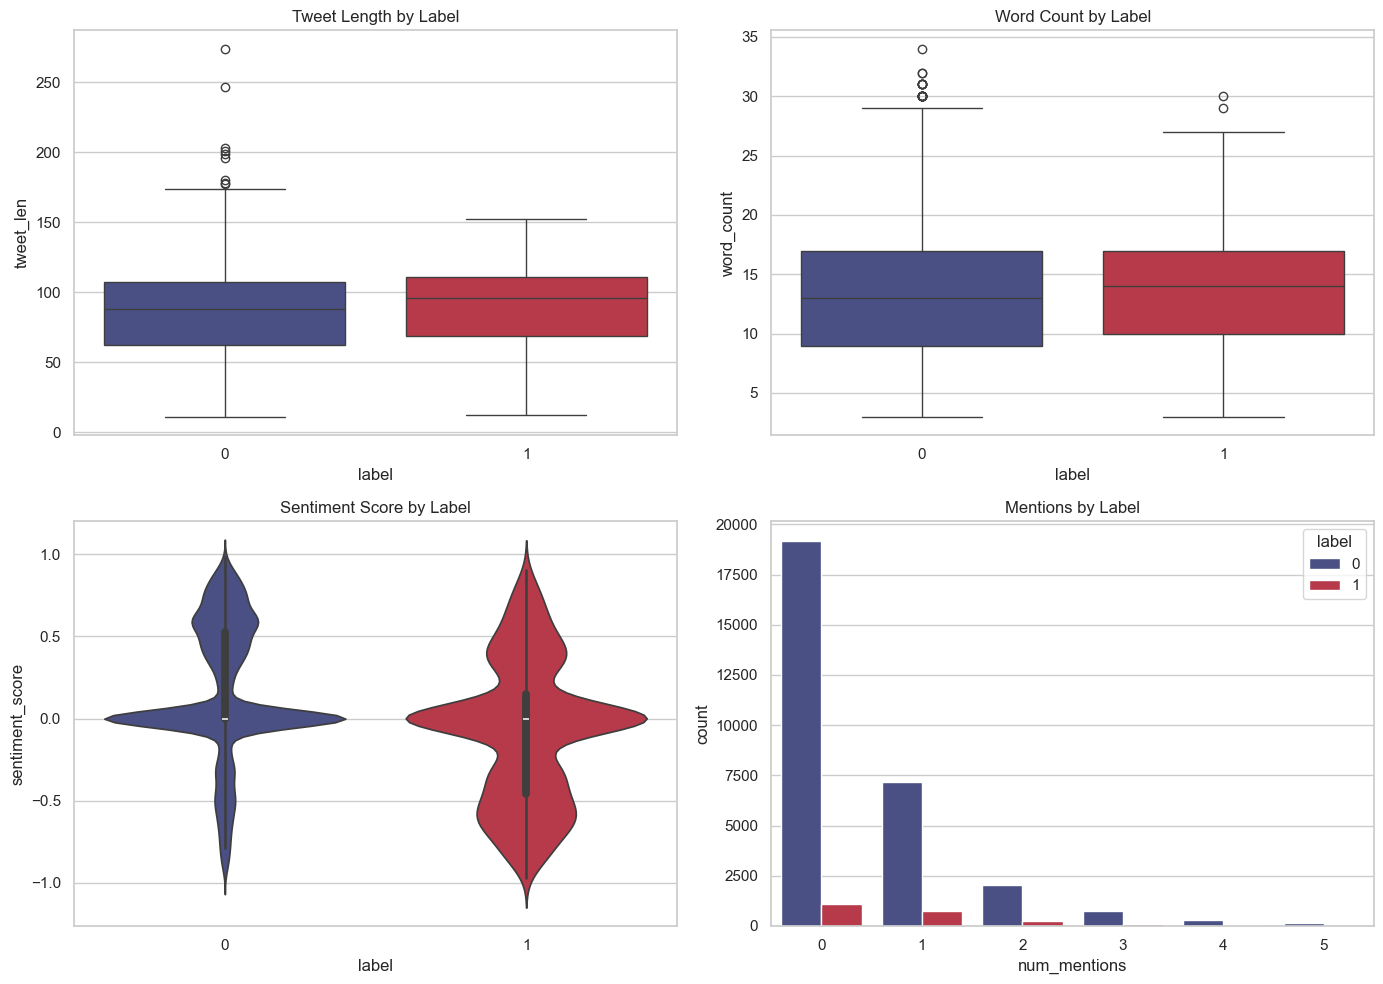

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tweet length
sns.boxplot(x="label", y="tweet_len", data=df, palette=bully_palette(df, "label", [1]), ax=axes[0, 0])
axes[0, 0].set_title("Tweet Length by Label")

# Word count
sns.boxplot(x="label", y="word_count", data=df, palette=bully_palette(df, "label", [1]), ax=axes[0, 1])
axes[0, 1].set_title("Word Count by Label")

# Sentiment score
sns.violinplot(x="label", y="sentiment_score", data=df, palette=bully_palette(df, "label", [1]), ax=axes[1, 0])
axes[1, 0].set_title("Sentiment Score by Label")

# Mentions
sns.countplot(x="num_mentions", hue="label", data=df, palette=bully_palette(df, "label", [1]), ax=axes[1, 1])
axes[1, 1].set_title("Mentions by Label")
axes[1, 1].set_xlim(-0.5, 5.5)

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

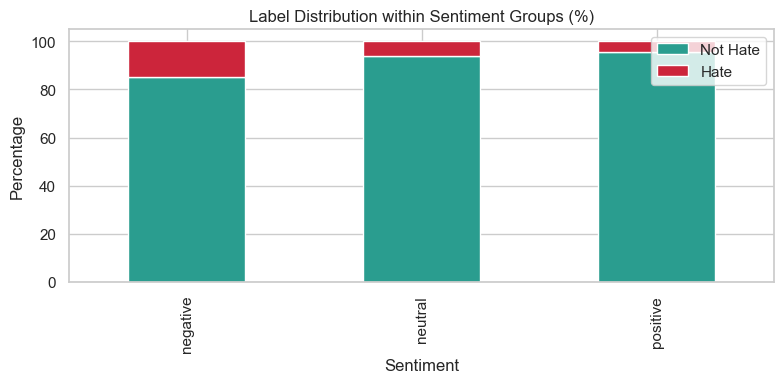


Sentiment × Label crosstab:
label          0     1    All
sentiment                    
negative    5091   872   5963
neutral    11964   765  12729
positive   12665   605  13270
All        29720  2242  31962


In [19]:
plt.figure(figsize=(8, 4))
ct = pd.crosstab(df["sentiment"], df["label"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, color=["#2a9d8f", "#cc253b"], figsize=(8, 4))
plt.title("Label Distribution within Sentiment Groups (%)")
plt.ylabel("Percentage")
plt.xlabel("Sentiment")
plt.legend(["Not Hate", "Hate"], loc="upper right")
plt.tight_layout()
plt.show()

print("\nSentiment × Label crosstab:")
print(pd.crosstab(df["sentiment"], df["label"], margins=True))

## 6. Correlation matrix

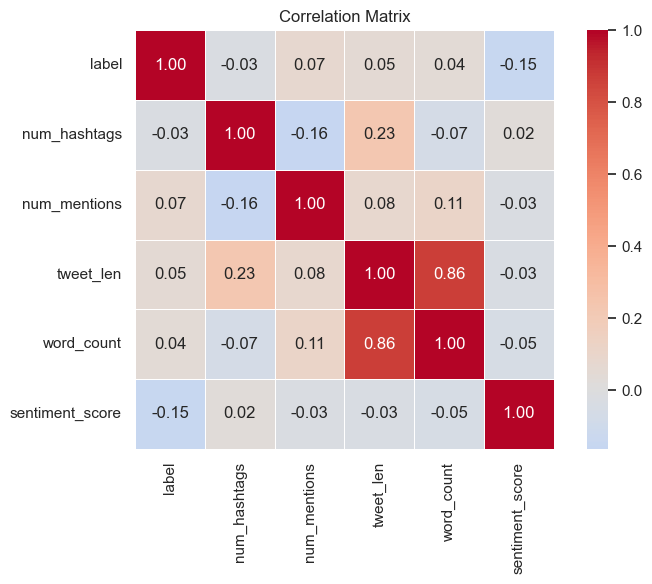

In [20]:
plt.figure(figsize=(8, 6))
numerical_df = df[["label", "num_hashtags", "num_mentions", "tweet_len", "word_count", "sentiment_score"]]
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 7. Word Clouds

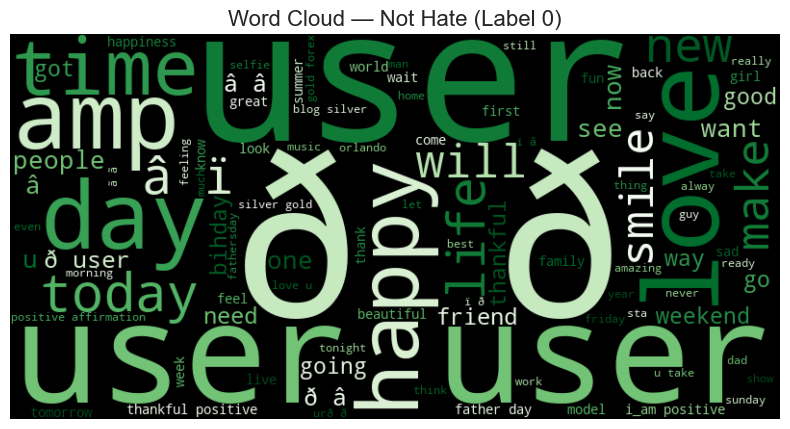

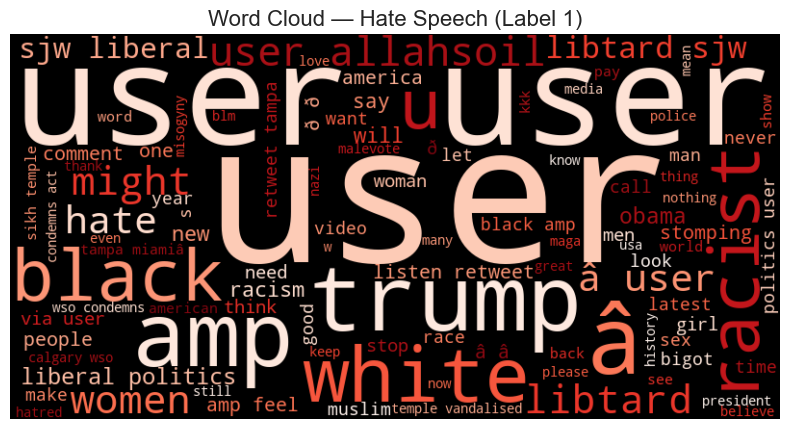

In [21]:
def plot_wordcloud(text, title, color_map):
    wc = WordCloud(background_color="black", width=800, height=400,
                   colormap=color_map, max_words=100).generate(str(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

non_bully_text = " ".join(df[df["label"] == 0]["tweet"].astype(str))
bully_text = " ".join(df[df["label"] == 1]["tweet"].astype(str))

plot_wordcloud(non_bully_text, "Word Cloud — Not Hate (Label 0)", "Greens")
plot_wordcloud(bully_text, "Word Cloud — Hate Speech (Label 1)", "Reds")

## 8. Conclusions

1. **Strong class imbalance** (93% vs 7%) — requires `class_weight='balanced'` or SMOTE during training.
2. **Accuracy is not a reliable metric** — even a naive model achieves ~93%. We use F1, Precision, Recall, ROC-AUC.
3. **Text features (TF-IDF)** provide more information than just tweet length and character count.
4. **Sentiment Score** has a weak correlation with the label — hate speech doesn't always have a negative tone.
5. **Word Clouds** show the difference in vocabulary between classes, confirming the usefulness of TF-IDF.